# PCHN63112 Workshop: Three-level Clustered Data Example
In this example,we will examine building a mixed-effects model for clustered data that contains three levels of variation. This will demonstrate how the multilevel framework extends beyond two levels, as well as how this can be integrated into a mixed-effects model.

## The Classroom Data
The data we will use concern measurements of improvement in maths ability in a selection of students from different classrooms across different schools. In total, these data contains measurements from 1,190 students from 312 classrooms from 107 schools. Importantly, these data were measured from first-graders in the USA (ages 6-7). As such, all students stay within the *same* classroom with the *same* teacher for the whole year. A wide variety of additional variables were captured describing the local area of the school, the teacher's experience and maths knowledge, and the student's demographic details. 

The data can be downloaded from [here](https://websites.umich.edu/~bwest/chapter4.html). Once downloaded to the current working directory, the code below will read the data into `R` and then print values for the first two classrooms from the first school

In [1]:
classroom <- read.csv('classroom.csv')
print(classroom[1:11,])

   sex minority mathkind mathgain   ses yearstea mathknow housepov mathprep
1    1        1      448       32  0.46        1       NA    0.082     2.00
2    0        1      460      109 -0.27        1       NA    0.082     2.00
3    1        1      511       56 -0.03        1       NA    0.082     2.00
4    0        1      449       83 -0.38        2    -0.11    0.082     3.25
5    0        1      425       53 -0.03        2    -0.11    0.082     3.25
6    1        1      450       65  0.76        2    -0.11    0.082     3.25
7    0        1      452       51 -0.03        2    -0.11    0.082     3.25
8    0        1      443       66  0.20        2    -0.11    0.082     3.25
9    1        1      422       88  0.64        2    -0.11    0.082     3.25
10   0        1      480       -7  0.13        2    -0.11    0.082     3.25
11   0        1      502       60  0.83        2    -0.11    0.082     3.25
   classid schoolid childid
1      160        1       1
2      160        1       2
3   

There are quite a few variables here, so we split them into those that relate to each *school* as a whole, each *classroom* as a whole and each *pupil* as a whole.

- School
    - `schoolid`: the unique index of each *school*
    - `housepov`: proportion of households in the local area below the poverty line
- Classroom
    - `classid`: the unique index of each *classroom*
    - `yearstea`: the teacher's years of experience
    - `mathprep`: the amount of training in mathematics education the teacher has undertaken
    - `mathknow`: the amount of mathematics knowledge the teacher has
- Student
    - `childid`: the unique index of each *student*
    - `mathgain`: **the student's gain in maths achievement over the year**
    - `sex`: the student's sex
    - `mathkind`: the student's maths score in the previous (kindergarten) year
    - `minority`: whether the student is from an ethnic minority background
    - `ses`: the student's socioeconomic status

Some of these variables are indices to keep things organised and to allow us to define different levels of the data: `schoolid`, `classid`, `childid`. The outcome variable is `mathgain`, highlighted in **bold**, indicative of how much the student has improved over the year spent in one particular classroom. This leaves *eight* potential predictor variables that could explain why some students improve more than others.

As these data are already long-formatted, we just need to convert the relevant variables to factors. We also choose to relabel both `sex` and `minority` to make their meaning clearer

In [2]:
classroom$classid  <- as.factor(classroom$classid)
classroom$schoolid <- as.factor(classroom$schoolid)
classroom$sex      <- as.factor(classroom$sex)
classroom$minority <- as.factor(classroom$minority)

levels(classroom$sex)      <- c('boy','girl')
levels(classroom$minority) <- c('nonminority', 'minority')

We can now briefly summarise all the variables. At this stage, we would usually produce some plots and do further data checking and wrangling, but we will leave this step to one side to keep the example shorter.

In [3]:
summary(classroom)

   sex             minority      mathkind        mathgain      
 boy :588   nonminority:384   Min.   :290.0   Min.   :-110.00  
 girl:602   minority   :806   1st Qu.:439.2   1st Qu.:  35.00  
                              Median :466.0   Median :  56.00  
                              Mean   :466.7   Mean   :  57.57  
                              3rd Qu.:495.0   3rd Qu.:  77.00  
                              Max.   :629.0   Max.   : 253.00  
                                                               
      ses              yearstea        mathknow          housepov     
 Min.   :-1.61000   Min.   : 0.00   Min.   :-2.5000   Min.   :0.0120  
 1st Qu.:-0.49000   1st Qu.: 4.00   1st Qu.:-0.7200   1st Qu.:0.0850  
 Median :-0.03000   Median :10.00   Median :-0.1300   Median :0.1270  
 Mean   :-0.01298   Mean   :12.21   Mean   : 0.0312   Mean   :0.1782  
 3rd Qu.: 0.39750   3rd Qu.:20.00   3rd Qu.: 0.8500   3rd Qu.:0.2550  
 Max.   : 3.21000   Max.   :40.00   Max.   : 2.6100   Max.   :

Some elements of note from these summaries:
- `sex` is balanced, so there is unlikely to be a bias here in terms of sex-related differences in attainment.
- `minority` indicates that the majority of the sample are from ethnic minority backgrounds ($806/(806+384) \times 100 = 67.73\%$).
- Some children have *negative* `mathgain` scores, indicating that they got *worse* over the year.
- There is a wide variation in `yearstea`, with some teachers having 40 years of experience and others having 0 years of teaching.
- There is also wide variation in `housepov`, with some school in area with very little poverty (1% of local houses) and some schools in areas with high poverty (56% of local houses).
- There are missing values in `mathknow`, as some teachers were not measured. 

### Model Notation
As these data are a mixture of *categorical* and *continuous* variables, a more general regression framework will be needed when writing this model. In what follows, we will use *descriptive labels* rather than greek letter for categorical variables (e.g. $\text{sex}_{j}$ rather than $\alpha_{j}$) and will introduce $\beta$-coefficients for continuous variables (e.g. $\beta_{1} \times \text{mathknow}_{i}$ rather than $\beta_{1}x_{i1}$). This should hopefully make it clearer which terms are categorical and which are continuous. In reality, the whole model is fit as a regression with dummy variables in place of the categorical predictors. However, it can be less clear to write the model this way, even if this is the reality of how it is fit.

## Data Structure
Although we already know what structure these data have, we will run through the logic for completeness.

Firstly, we need to determine our *unit of analysis*. In this example, our model is trying to explain improvements in maths scores in *students*. The entities that our model is describing are the *students* themselves, so these are our units of analysis.

Secondly, we determine what each *row* of the long-formatted data represents in relation to the units of analysis. Examining the first few rows

In [4]:
head(classroom)

   sex minority mathkind mathgain   ses yearstea mathknow housepov mathprep
1 girl minority      448       32  0.46        1       NA    0.082     2.00
2  boy minority      460      109 -0.27        1       NA    0.082     2.00
3 girl minority      511       56 -0.03        1       NA    0.082     2.00
4  boy minority      449       83 -0.38        2    -0.11    0.082     3.25
5  boy minority      425       53 -0.03        2    -0.11    0.082     3.25
6 girl minority      450       65  0.76        2    -0.11    0.082     3.25
  classid schoolid childid
1     160        1       1
2     160        1       2
3     160        1       3
4     217        1       4
5     217        1       5
6     217        1       6

we can see that each row corresponds to a single unit (*student*) measured *once*. So these are neither repeated measurements or longitudinal data. 

Finally, we need to determine whether there are any *clustering* variables that represent a higher-order dependency structure in these data. From what we can see above, there are several variables that are *constant* across multiple students: `yearstea`, `mathknow`, `housepov`, `mathprep`, `classid` and `schoolid`. Of those, only `classid` and `schoolid` are categorical and so are the only candidates for either *grouping variables* or *clustering variables*. 

In terms of thinking about clustering variables as representative of a *shared environment*, both `classid` and `schoolid` fit the description. These are both elements that each student is *IN* rather than something each student *HAS*. Students within a classroom may be correlated by virtue of sharing a teacher, sharing the same corpus of classmates and sharing the same teaching environment. Similarly, classrooms within a school may be correlated by virtue of sharing the same physical location, the same school budget and the same senior members of staff. The different schools represent the top boundary of dependence, because different schools will be independent of each other. Within a school, each classroom will have a degree of independence, as these are separate entities. However, they will also share a degree of dependence due to being within the same school. So this is a separate boundary of dependence. We imagine these as smaller covariance blocks within a larger covariance block.

Based on this, we can construct the following table of the *levels* of these data, using the guidance in the lesson

| **Data Type**    | **Clustered** | 
|------------------|---------------|
| **Dataset**      | `classroom`   |
| **Level 1**      | *Student*     |
| **Level 2**      | Classroom     |
| **Level 3**      | School        |

We could also imagine a more complex version of these data, where each student was measured at multiple points within a year. This would then be *longitudinal* clustered data with *four* levels. We would have the longitudinal measurements at Level 1, student at Level 2, classroom at Level 3 and school at Level 4. This would lead to quite a complex dependency structure that would be very difficult to reason about and build using a method like GLS. However, the mixed-effects framework allows us to build this carefully in layers, without every having to touch the covariance structure.

## Model Building
To build a model of this dataset, we use the 3-step procedure outlined in the lesson. We assume at this point that the data has been investigated, wrangled, cleaned and ready for modelling.

### Step I: A Single Dependency Structure
We start by isolating a single dependency structure. This needs to be at the *lowest* level, with no further dependency structures within. In this example, this is a single *classroom*. We choose `classid == '174'` for this purpose, after examining several candidates. This was chosen because it contains a reasonable number of measurements (7 students), has no missing data and has representation of *both* levels of `minority`. During this exploration, it was notable that many classrooms are *constant* in terms of `minority`, which will be important to bear in mind when fitting the model. 

In [5]:
classroom.1 <- subset(classroom, classid=='174')
print(classroom.1)

     sex    minority mathkind mathgain   ses yearstea mathknow housepov
912 girl    minority      474       90  0.04       11     1.75     0.21
913  boy nonminority      430       74 -0.03       11     1.75     0.21
914 girl nonminority      452       44 -0.67       11     1.75     0.21
915 girl nonminority      428       53 -0.42       11     1.75     0.21
916  boy    minority      452       66 -0.73       11     1.75     0.21
917 girl nonminority      485       40 -0.78       11     1.75     0.21
918 girl    minority      458       48 -0.44       11     1.75     0.21
    mathprep classid schoolid childid
912        2     174       81     912
913        2     174       81     913
914        2     174       81     914
915        2     174       81     915
916        2     174       81     916
917        2     174       81     917
918        2     174       81     918


In terms of the variables suitable for an individual model of a single classroom, we note that many of the variables above are *constant* because they are defined either at the level of a *classroom* as a whole, or a *school* as a whole. As such, they are not suitable for modelling the individual students. We remove these below 

In [6]:
classroom.1 <- subset(classroom, classid=='174', select=c(-yearstea,-mathknow,-housepov,-mathprep,-classid,-schoolid))
print(classroom.1)

     sex    minority mathkind mathgain   ses childid
912 girl    minority      474       90  0.04     912
913  boy nonminority      430       74 -0.03     913
914 girl nonminority      452       44 -0.67     914
915 girl nonminority      428       53 -0.42     915
916  boy    minority      452       66 -0.73     916
917 girl nonminority      485       40 -0.78     917
918 girl    minority      458       48 -0.44     918


Based on this, our basic model for a single classroom is

$$
\text{mathgain}_{ijk} = \text{mean} + \text{sex}_{j} + \text{minority}_{k} + (\beta_{1} \times \text{mathkind}_{i}) + (\beta_{2} \times \text{ses}_{i}) + \eta_{ijk}
$$

where $i$ indexes the student, $j$ indexes `sex` and $k$ indexes `minority`. Both $\text{sex}_{j}$ and $\text{minority}_{k}$ are indicative of categorical effects, whereas $\text{mathkind}_{i}$ and $\text{ses}_{i}$ are indicative of continuous predictors with associated regression slopes $\beta_{1}$ and $\beta_{2}$.

We can fit this model in `R` as shown below

In [7]:
class.1.lm <- lm(mathgain ~ 1 + sex + minority + mathkind + ses, data=classroom.1)
summary(class.1.lm)


Call:
lm(formula = mathgain ~ 1 + sex + minority + mathkind + ses, 
    data = classroom.1)

Residuals:
    912     913     914     915     916     917     918 
  6.898  -5.146   2.530   4.895   5.146  -2.279 -12.043 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)
(Intercept)        8.9519   125.7963   0.071    0.950
sexgirl          -14.1331    11.4198  -1.238    0.341
minorityminority   7.8017    10.3018   0.757    0.528
mathkind           0.1662     0.2936   0.566    0.628
ses               42.4991    15.7473   2.699    0.114

Residual standard error: 11.86 on 2 degrees of freedom
Multiple R-squared:  0.8578,	Adjusted R-squared:  0.5735 
F-statistic: 3.017 on 4 and 2 DF,  p-value: 0.2641


However, notice that there are only 2 residual degrees of freedom left, because we have fit 5 parameters to 7 datapoints. If we had fewer students in this class, the model would fail to fit. Unfortunately, the data are quite limited for most of the classrooms in this dataset. To see this, we use the code below to select 20 random classrooms and then plot them as panels with `sex` on the $x$-axis and different symbols used to indicate the levels of `minority`.

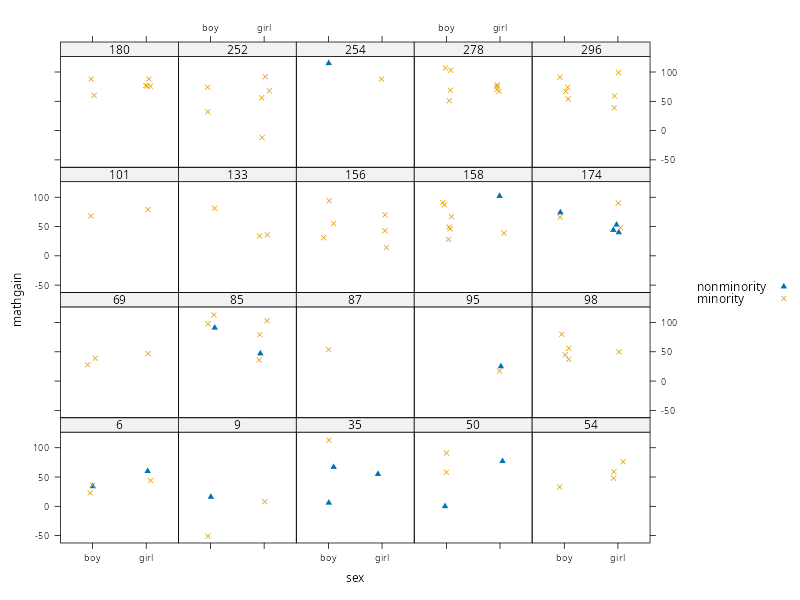

In [8]:
library('lattice')

set.seed(666)
keep.IDs <- sample(unique(classroom$classid), 20)      # select 20 random class IDs

xyplot(mathgain ~ sex | classid,                       # x-axis=sex, panels=classroom
  groups   = minority,                                 # minority different symbols
  data     = subset(classroom, classid %in% keep.IDs), # only random class IDs
  type     = "p",                                      # points (not joined)
  auto.key = TRUE,                                     # add key
  jitter.x = TRUE,                                     # jitter points for visibility
  par.settings = list(
    superpose.symbol = list(
      pch = c(17,4)                                    # symbols to triangle and cross
    )
  )
)

As we can see, some classrooms have much less data than others. In many cases, there is only a single level of `minority` represented. Some classrooms only have a single student who was measured, whereas in others multiple students were measured but only of one `sex`. This suggests already that data will need be to pooled across classrooms in order to estimate the effects of `sex` and `minority`, potentially precluding the idea of allowing `sex` and `minority` to vary per-classroom.

### Step II: Expand to Multiple Structures
In our second step, we expand the model above to *multiple* classrooms. We index these using the notation of $(c)$, to indicate which terms *belong* to a particular *classroom*. We start with the most general case of allowing every term to vary by-classroom, giving us

$$
\text{mathgain}^{(c)}_{ijk} = \text{mean}^{(c)} + \text{sex}^{(c)}_{j} + \text{minority}^{(c)}_{k} + \left(\beta_{1}^{(c)} \times \text{mathkind}_{i}\right) + \left(\beta_{2}^{(c)} \times \text{ses}_{i}\right) + \eta^{(c)}_{ijk}
$$

We can now reason more carefully about each of these.

In terms of $\text{mean}^{(c)}$, if we want to use a mixed-effects models then the bear minimum is a *random intercept* term. Allowing $\text{mean}^{(c)}$ to differ per-classroom implies that each classroom is a random sample from a distribution of classrooms. The degree of $\text{mathgain}$ depends upon the specific classroom environment and the specific teacher, rather than being the same across all classrooms. If it were the same, this would imply that any differences across students are down to the student's own characteristics and it would not matter if the student was in a different classroom or in a different school. In this scenario, the classroom has no bearing on the outcome. Instead, we can choose treat each classroom as a distribution of $\text{mathgain}$ scores with its own specific average value of $\text{mathgain}$ that will differ from other classrooms. In this scenario, the classroom *does* have an effect on the outcome, implying that an individual student may perform differently in a different classroom. In addition, given that `classroom` is our clustering variable, it is usually sensible to treat this as *random* rather than *fixed*.

The remaining terms in this individual-classroom model present something of a challenge. For each of these, consider the implication of treating them as *random* rather than *fixed*

- $\text{sex}^{(c)}_{j}$ &mdash; Any differences in $\text{mathgain}$ between boys and girls depends upon the classroom environment, with some teachers able to close gaps and some potentially widening gaps.
- $\text{minority}^{(c)}_{k}$ &mdash; Any differences in $\text{mathgain}$ between minority and non-minority children depends upon the classroom environment, with some teachers able to close gaps and some potentially widening gaps.
- $\beta_{1}^{(c)}$ &mdash; The relationship between a student's kindergarten score and their eventual value of $\text{mathgain}$ depends upon the classroom environment, with some teachers associated with a much stronger relationship than others.
- $\beta_{2}^{(c)}$ &mdash; The relationship between a student's socioeconomic status their eventual value of $\text{mathgain}$ depends upon the classroom environment, with some teachers associated with a much stronger relationship than others.

In all cases, simply reasoning about these terms will depend upon how much we believe teachers are able to influence individual students, despite their characteristics. This can get a bit philosophical, depending upon whether we believe students are handed to teachers as a *tabula rasa*, available for molding in whatever shape the teacher desires, or whether there are pre-existing characteristics of each student that will dictate performance, despite the efforts of individual teachers. Certainly, we could imagine individual teachers who are able to create an environment where students can excel irrespective of these factors, but do we believe this is something that varies enough across different classrooms and schools to offset any strong global pattern, or would this just effectively be sampling noise?

We could also take a more data-driven approach to this decision. For instance, we could plot the data for `mathkind` within those classrooms randomly sampled earlier

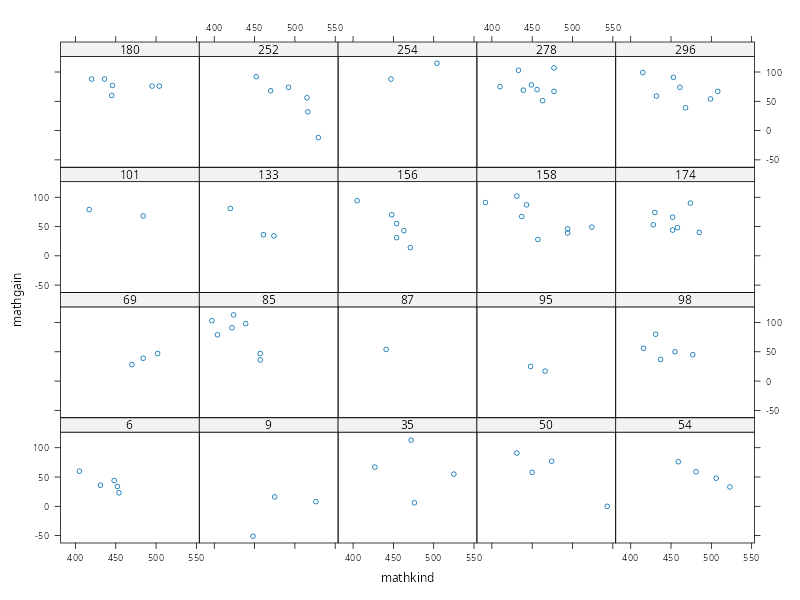

In [9]:
xyplot(mathgain ~ mathkind | classid,              # x-axis=mathkind, panels=classroom
  data = subset(classroom, classid %in% keep.IDs), # only random class IDs
  type = "p",                                      # points (not joined)
)

Unfortunately, there is no immediately obvious pattern either within individual classrooms or across all classrooms. This could be suggestive that `mathkind` is simply not a useful predictor, but at this stage it does not help with the question of *random* or *fixed*. This is very similar across all other variables, meaning that the data-driven approach is less useful here. We need to therefore use reason, practical limitations and model comparisons to make a decision.



It was recommended in the accompanying lesson that in cases of uncertainty we simply treat everything as random and then use model comparisons. However, there is a catch with this approach. If we do this here, then we have 5 random effects, which will mean 5 error terms and 5 variances, as well as correlations between all of them. This tends to be too much for most random effects algorithms. So even if we desire this *theoretically*, in terms of *practicality* we will be forced to simplify. Nervousness about fitting this model is also justified when we consider that the amount of data per-classroom is very limited, with only a small number that would be able to fit the full model we want. This means that a lot of pooling and shrinkage will be going on, with many of the effects based on *no data* for that particular classroom. Indeed, the average number of students per-classroom is

In [10]:
mean(table(classroom$classid))

[1] 3.814103

which is *very small*. Realistically, if we want the full random-effects specification we need *much larger* samples within each classroom. Of course, we could power through and see whether a model with all these random terms can be fit, but we will save you the trouble and tell you that it *cannot*. This is more of a *brute force* approach, which we do not recommend, but ultimately there is no harm in trying. So, we do need to simplify at this point. 

On the basis that it quite a strong assumption to think that individual teachers are able to undo any fundamental effects of sex, minority status, existing maths achievement and socioeconomic status, we choose to treat all these terms as *fixed*, leaving only the intercept as *random*. This implies that individual teachers and classroom environments are able to raise or lower all values of $\text{mathgain}$ by some amount. So, under some teachers all students do better or worse, like a rising tide lifting all boats. However, *within* those students, there are global effects of sex, minority status, prior achievement and socioeconomic status that are in play that do not depend upon an individual teacher or classroom environment. Although this does create something of a *fatalistic* perspective on student performance, it does have the benefit of greatly simplifying the random-effects structure. 

### Step III: Write the Higher-level Models
Now that we have made a decision about all the Level 1 terms, we can write the Level 2 models for each term. As $\text{mean}^{(c)}$ is the only *random* term, it is the only Level 2 model with an error term. This gives

$$
\begin{alignat*}{1}
\text{Level 1 (Student)} \\
    \text{mathgain}^{(c)}_{ijk} &= \text{mean}^{(c)} + \text{sex}^{(c)}_{j} + \text{minority}^{(c)}_{k} + \left(\beta^{(c)}_{1} \times \text{mathkind}_{i}\right) + \left(\beta_{2}^{(c)} \times \text{ses}_{i}\right) + \eta^{(c)}_{ijk} \\ \quad \\
\text{Level 2 (Classroom)} \\
    \text{mean}^{(c)}         &= \text{mean} + \xi^{(c)} \\
    \text{sex}^{(c)}_{j}      &= \text{sex}_{j}  \\
    \text{minority}^{(c)}_{k} &= \text{minority}_{k} \\  
    \beta^{(c)}_{1}           &= \beta_{1} \\
    \beta^{(c)}_{2}           &= \beta_{2}.
\end{alignat*}
$$

At this point, we can decide whether there are any classroom-level variables we also want to include in these models. Looking back to our data description from earlier, the additional variables we have available are `yearstea`, `mathprep` and `mathknow`. These apply to individual teachers *as a whole* and thus could be used to explain average `mathgain` for a whole class. As such, our first option is to add these variables as predictors of $\text{mean}^{(c)}$, giving

$$
\begin{alignat*}{1}
\text{Level 1 (Student)} \\
    \text{mathgain}^{(c)}_{ijk} &= \text{mean}^{(c)} + \text{sex}^{(c)}_{j} + \text{minority}^{(c)}_{k} + \left(\beta^{(c)}_{1} \times \text{mathkind}_{i}\right) + \left(\beta_{2}^{(c)} \times \text{ses}_{i}\right) + \eta^{(c)}_{ijk} \\ \quad \\
\text{Level 2 (Classroom)} \\
    \text{mean}^{(c)}         &= \text{mean} + \left(\beta_{3} \times \text{yearstea}^{(c)}\right) + \left(\beta_{4} \times \text{mathprep}^{(c)}\right) + \left(\beta_{5} \times \text{mathknow}^{(c)}\right) + \xi^{(c)} \\
    \text{sex}^{(c)}_{j}      &= \text{sex}_{j}  \\
    \text{minority}^{(c)}_{k} &= \text{minority}_{k} \\  
    \beta^{(c)}_{1}           &= \beta_{1} \\
    \beta^{(c)}_{2}           &= \beta_{2}.
\end{alignat*}
$$

Our next option is whether to include these predictor within the models for the remaining effects of `sex`, `minority`, `mathkind` and `ses`. Because these are models of individual effects, any additional predictors will enter as *interactions* with that effect. In order to keep things simple, we will not entertain the possibility of interactions here. In general, we would need strong reasons for including them, given that additional complexity they add.

#### Expand to Multiple Schools
At this point, we have a perfectly useable two-level model that would be suitable for *one school*. However, we know that we have an additional level of clustering in the form of *individual schools*. This means we need to repeat some of our process from above, but for Level 2 instead. 

So, let us take the Level 2 specification and expand it to *multiple schools*. We will use a similar notation to earlier, where terms that can differ by school are indicated by superscript $(s)$. If we start by allowing every term to vary by-school, we get

$$
\begin{alignat*}{1}
\text{Level 2} \\
    \text{mean}^{(c)}         &= \text{mean}^{(s)} + \left(\beta_{3}^{(s)} \times \text{yearstea}^{(c)}\right) + \left(\beta_{4}^{(s)} \times \text{mathprep}^{(c)}\right) + \left(\beta_{5}^{(s)} \times \text{mathknow}^{(c)}\right) + \xi^{(c)} \\
    \text{sex}^{(c)}_{j}      &= \text{sex}^{(s)}_{j}  \\
    \text{minority}^{(c)}_{k} &= \text{minority}^{(s)}_{k} \\  
    \beta^{(c)}_{1}           &= \beta_{1}^{(s)} \\
    \beta^{(c)}_{2}           &= \beta_{2}^{(s)} \\ \quad \\
\end{alignat*}
$$

So, we now have to work through each of the new school-specific terms and decide whether to treat them as *fixed* or *random*. This is a similar process to reasoning about individual classrooms. ... The final step is then deciding whether there are any *school-level* variables that we wish to include in the Level 3 models ... Based on all the above, the Level 3 specification is

$$
\begin{alignat*}{1}
\text{Level 3 (School)} \\
    \text{mean}^{(s)} &= \text{mean} + \left(\beta_{6} \times \text{housepov}^{(s)}\right) + \phi^{(s)} \\
    \text{sex}^{(s)}_{j} &= \text{sex}_{j} \\
    \text{minority}^{(s)}_{k} &= \text{minority}_{k} \\
    \beta_{1}^{(s)} &= \beta_{1} \\
    \beta_{2}^{(s)} &= \beta_{2}\\
    \beta_{3}^{(s)} &= \beta_{3} \\
    \beta_{4}^{(s)} &= \beta_{4} \\
    \beta_{5}^{(s)} &= \beta_{5} \\
\end{alignat*}
$$

#### The Final Model (Full and Simplified)
The full model is now (*deep breath*)

$$
\begin{alignat*}{1}
\text{Level 1 (Student)} \\
    \text{mathgain}^{(c)}_{ijk} &= \text{mean}^{(c)} + \text{sex}^{(c)}_{j} + \text{minority}^{(c)}_{k} + \left(\beta^{(c)}_{1} \times \text{mathkind}_{i}\right) + \left(\beta_{2}^{(c)} \times \text{ses}_{i}\right) + \eta^{(c)}_{ijk} \\ \quad \\
\text{Level 2 (Classroom)} \\
    \text{mean}^{(c)}         &= \text{mean}^{(s)} + \left(\beta_{3}^{(s)} \times \text{yearstea}^{(c)}\right) + \left(\beta_{4}^{(s)} \times \text{mathprep}^{(c)}\right) + \left(\beta_{5}^{(s)} \times \text{mathknow}^{(c)}\right) + \xi^{(c)} \\
    \text{sex}^{(c)}_{j}      &= \text{sex}^{(s)}_{j}  \\
    \text{minority}^{(c)}_{k} &= \text{minority}^{(s)}_{k} \\  
    \beta^{(c)}_{1}           &= \beta_{1}^{(s)} \\
    \beta^{(c)}_{2}           &= \beta_{2}^{(s)} \\ \quad \\
\text{Level 3 (School)} \\
    \text{mean}^{(s)} &= \text{mean} + \left(\beta_{6} \times \text{housepov}^{(s)}\right) + \phi^{(s)} \\
    \text{sex}^{(s)}_{j} &= \text{sex}_{j} \\
    \text{minority}^{(s)}_{k} &= \text{minority}_{k} \\
    \beta_{1}^{(s)} &= \beta_{1} \\
    \beta_{2}^{(s)} &= \beta_{2}\\
    \beta_{3}^{(s)} &= \beta_{3} \\
    \beta_{4}^{(s)} &= \beta_{4} \\
    \beta_{5}^{(s)} &= \beta_{5} \\
\end{alignat*}
$$

which is pretty complicated and unwieldly. However, we can simplify this dramatically by first collapsing the fixed Level 3 terms back into Level 2 

$$
\begin{alignat*}{1}
\text{Level 1} \\
    \text{mathgain}^{(c)}_{ijk} &= \text{mean}^{(c)} + \text{sex}^{(c)}_{j} + \text{minority}^{(c)}_{k} + \left(\beta^{(c)}_{1} \times \text{mathkind}_{i}\right) + \left(\beta_{2}^{(c)} \times \text{ses}_{i}\right) + \eta^{(c)}_{ijk} \\ \quad \\
\text{Level 2} \\
    \text{mean}^{(c)}         &= \text{mean}^{(s)} + \left(\beta_{3} \times \text{yearstea}^{(c)}\right) + \left(\beta_{4} \times \text{mathprep}^{(c)}\right) + \left(\beta_{5} \times \text{mathknow}^{(c)}\right) + \xi^{(c)} \\
    \text{sex}^{(c)}_{j}      &= \text{sex}_{j}  \\
    \text{minority}^{(c)}_{k} &= \text{minority}_{k} \\  
    \beta^{(c)}_{1}           &= \beta_{1} \\
    \beta^{(c)}_{2}           &= \beta_{2} \\ \quad \\
\text{Level 3} \\
    \text{mean}^{(s)} &= \text{mean} + \left(\beta_{6} \times \text{housepov}^{(s)}\right) + \phi^{(s)} \\
\end{alignat*}
$$

and then collapsing the fixed Level 2 terms back into Level 1

$$
\begin{alignat*}{1}
\text{Level 1 (Student)} \\
    \text{mathgain}^{(c)}_{ijk} &= \text{mean}^{(c)} + \text{sex}_{j} + \text{minority}_{k} + \left(\beta_{1} \times \text{mathkind}_{i}\right) + \left(\beta_{2} \times \text{ses}_{i}\right) + \eta^{(c)}_{ijk} \\ \quad \\
\text{Level 2 (Classroom)} \\
    \text{mean}^{(c)}         &= \text{mean}^{(s)} + \left(\beta_{3} \times \text{yearstea}^{(c)}\right) + \left(\beta_{4} \times \text{mathprep}^{(c)}\right) + \left(\beta_{5} \times \text{mathknow}^{(c)}\right) + \xi^{(c)} \\ \quad \\
\text{Level 3 (School)} \\
    \text{mean}^{(s)} &= \text{mean} + \left(\beta_{6} \times \text{housepov}^{(s)}\right) + \phi^{(s)} \\
\end{alignat*}
$$

So now the model form should be much clearer. We are assuming 3 separate distributions for the data. The highest-level distribution represents the population of all schools. The next level represents the distribution of classes within a single school, and the lowest-level represents the distribution of students within a single class from a single school. The average attainment score of a school is influenced by the population average attainment plus the effect of local poverty. The average attainment within a single class is influence by the school average plus effects associated with the teacher of that class. Finally, the attainment of a single pupil is influenced by the class average  plus effects associated with their own personal characteristics and background.

## Fitting the Model in `R`

$$
\begin{alignat*}{2}
\text{mathgain}^{(c)}_{ijk} &= &\text{mean} + \text{sex}_{j} + \text{minority}_{k} + \left(\beta_{1} \times \text{mathkind}_{i}\right) + \left(\beta_{2} \times \text{ses}_{i}\right) + \\
                                &&\left(\beta_{3} \times \text{yearstea}^{(c)}\right) + \left(\beta_{4} \times \text{mathprep}^{(c)}\right) + \left(\beta_{5} \times \text{mathknow}^{(c)}\right) + \\
                                &&\left(\beta_{6} \times \text{housepov}^{(s)}\right) + \\
                                &&\phi^{(s)} + \xi^{(c)} + \eta^{(c)}_{ijk}
\end{alignat*}
$$

... Notice that these terms have *different* clustering superscripts, implying that we need both `1|classid` and `1|schoolid` in the model. The way we specify this is by passing a `list` to the `random=` option. Within this list, we label each field using the clustering variable and then give the model formula. Due to the labelling, the conditional syntax is implied and does not need to be given explicitly. So, for both `1|classid` and `1|schoolid` we can use `list(classid = ~ 1, schoolid = ~ 1)`. This gives us full control of the random-effects specification at each level. For instance, if we had decided to let the effect of `sex` vary across schools, but wanted it fixed across classes, we could use `list(classid = ~ 1, schoolid = ~ 1 + sex)`.

In [13]:
library('nlme')

classroom.lme <- lme(fixed  = mathgain ~ 1 + sex + minority + mathkind + ses + yearstea + mathprep + mathknow + housepov,
                     random = list(classid  = ~ 1,
                                   schoolid = ~ 1),
                     data=classroom,
                     control=lmeControl(opt='optim'),
                     na.action = na.omit
)

print(classroom.lme)

Linear mixed-effects model fit by REML
  Data: classroom 
  Log-restricted-likelihood: -5159.077
  Fixed: mathgain ~ 1 + sex + minority + mathkind + ses + yearstea + mathprep +      mathknow + housepov 
     (Intercept)          sexgirl minorityminority         mathkind 
     280.5753000       -1.1818489       -7.5017659       -0.4700709 
             ses         yearstea         mathprep         mathknow 
       5.1755649        0.0476315        1.0794518        0.8819618 
        housepov 
      -5.6236280 

Random effects:
 Formula: ~1 | classid
        (Intercept)
StdDev:    9.063104

 Formula: ~1 | schoolid %in% classid
        (Intercept) Residual
StdDev:    9.063104 26.71224

Number of Observations: 1081
Number of Groups: 
              classid schoolid %in% classid 
                  285                   285 
